In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install torch torchvision
# The following must match your Torch/CUDA version.
# If on Colab, just run:
!pip install torch_geometric
!pip install pandas numpy scikit-learn matplotlib

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 49.2 MB/s eta 0:00:00


In [7]:
import pandas as pd
import numpy as np
import os
import torch
from google.colab import drive
from torch_geometric.data import Data

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Define Paths
base_path = '/content/drive/MyDrive/Projects/bitcoinFraudDetection'
os.makedirs(base_path, exist_ok=True)

# Define specific file paths
classes_file = os.path.join(base_path, 'elliptic_txs_classes.csv')
features_file = os.path.join(base_path, 'elliptic_txs_features.csv')
edges_file    = os.path.join(base_path, 'elliptic_txs_edgelist.csv')

# 3. Download Logic (Robust Check)
files_to_download = {
    'elliptic_txs_classes.csv': 'https://raw.githubusercontent.com/manurag20/elliptic_fraud_detection/main/elliptic_dataset/elliptic_txs_classes.csv',
    'elliptic_txs_features.csv': 'https://raw.githubusercontent.com/manurag20/elliptic_fraud_detection/main/elliptic_dataset/elliptic_txs_features.csv',
    'elliptic_txs_edgelist.csv': 'https://raw.githubusercontent.com/manurag20/elliptic_fraud_detection/main/elliptic_dataset/elliptic_txs_edgelist.csv'
}

print("Checking data files...")
for filename, url in files_to_download.items():
    file_path = os.path.join(base_path, filename)

    # Download if file doesn't exist OR is empty
    if not os.path.exists(file_path) or os.path.getsize(file_path) == 0:
        print(f"Downloading {filename}...")
        !wget -q -O "{file_path}" "{url}"

        # Verify download
        if not os.path.exists(file_path) or os.path.getsize(file_path) == 0:
            raise FileNotFoundError(f"Failed to download {filename}. Check URL.")
    else:
        print(f"✅ {filename} found.")

# 4. Load & Clean Data
print("\nLoading DataFrames...")
# Features file has no header
df_classes = pd.read_csv(classes_file)
df_features = pd.read_csv(features_file, header=None)
df_edges = pd.read_csv(edges_file)

# Rename feature columns
col_names = ['txId', 'time_step'] + [f'feat_{i}' for i in range(165)]
df_features.columns = col_names

# Filter 'unknown' classes
clean_classes = df_classes[df_classes['class'] != 'unknown'].copy()
# Map labels: 1=Illicit (Fraud), 2=Licit (Normal) -> 1=Fraud, 0=Normal
clean_classes['label'] = clean_classes['class'].map({'1': 1, '2': 0})

# Merge features with valid classes
df_merge = df_features.merge(clean_classes, on='txId', how='inner')

print(f"Labeled Transactions: {len(df_merge)}")
print(f"Fraud Ratio: {df_merge['label'].mean():.4f}")

# 5. Build the Graph (PyTorch Geometric)
print("\nConstructing Graph Object...")

# Map Transaction IDs to sequential indices (0, 1, 2...)
sorted_txIds = df_merge['txId'].unique()
map_id = {tx_id: i for i, tx_id in enumerate(sorted_txIds)}

# Map Edge IDs
# Only keep edges where BOTH nodes exist in our labeled set
df_edges_clean = df_edges[
    df_edges['txId1'].isin(df_merge['txId']) &
    df_edges['txId2'].isin(df_merge['txId'])
]

src_nodes = df_edges_clean['txId1'].map(map_id).values
dst_nodes = df_edges_clean['txId2'].map(map_id).values
edge_index = torch.tensor([src_nodes, dst_nodes], dtype=torch.long)

# Prepare Features (x) and Labels (y)
df_merge['node_id'] = df_merge['txId'].map(map_id)
df_merge = df_merge.sort_values('node_id')

feature_cols = ['time_step'] + [f'feat_{i}' for i in range(165)]
x = torch.tensor(df_merge[feature_cols].values, dtype=torch.float)
y = torch.tensor(df_merge['label'].values, dtype=torch.float)

# Create Data Object
data = Data(x=x, edge_index=edge_index, y=y)

# Create Temporal Split Masks
# Train on first 34 time steps, Test on remaining
time_step = data.x[:, 0]
train_mask = time_step <= 34
test_mask = time_step > 34

print("✅ Graph Ready!")
print(data)
print(f"Train Nodes: {train_mask.sum().item()}")
print(f"Test Nodes:  {test_mask.sum().item()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking data files...
✅ elliptic_txs_classes.csv found.
✅ elliptic_txs_features.csv found.
✅ elliptic_txs_edgelist.csv found.

Loading DataFrames...
Labeled Transactions: 46564
Fraud Ratio: 0.0976

Constructing Graph Object...
✅ Graph Ready!
Data(x=[46564, 166], edge_index=[2, 36624], y=[46564])
Train Nodes: 29894
Test Nodes:  16670


/tmp/ipython-input-290062485.py:80: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  edge_index = torch.tensor([src_nodes, dst_nodes], dtype=torch.long)


In [9]:
# This step is redundant. The graph object 'data' was already constructed
# and loaded in the previous cell.

# The error occurred because this code tries to read files from the current directory,
# but they are stored in '/content/drive/MyDrive/Projects/bitcoinFraudDetection'.

print("Graph construction already completed in the previous cell.")
print("Current Data Object:", data)

Graph construction already completed in the previous cell.
Current Data Object: Data(x=[46564, 166], edge_index=[2, 36624], y=[46564])


In [10]:
# The 'time_step' feature (column 0 in x) goes from 1 to 49.
# We will use 1-34 for Training, and 35-49 for Testing.

time_step = data.x[:, 0]

train_mask = time_step <= 34
test_mask = time_step > 34

print(f"Training Nodes: {train_mask.sum()}")
print(f"Testing Nodes: {test_mask.sum()}")

Training Nodes: 29894
Testing Nodes: 16670


In [11]:
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class FraudGNN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(FraudGNN, self).__init__()
        # Layer 1: Look at immediate neighbors
        # in_channels = 167 (features), out_channels = 128 (embedding size)
        self.conv1 = SAGEConv(in_channels, hidden_channels)

        # Layer 2: Look at neighbors' neighbors
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        # 1. First Message Passing Layer
        x = self.conv1(x, edge_index)
        x = x.relu() # Activation function
        x = F.dropout(x, p=0.5, training=self.training) # Dropout to prevent overfitting

        # 2. Second Message Passing Layer
        x = self.conv2(x, edge_index)

        # Note: We do NOT use Sigmoid here.
        # We will use BCEWithLogitsLoss later which includes Sigmoid.
        return x

# Initialize Model
model = FraudGNN(in_channels=data.num_features, hidden_channels=128, out_channels=1)
print(model)

FraudGNN(
  (conv1): SAGEConv(166, 128, aggr=mean)
  (conv2): SAGEConv(128, 1, aggr=mean)
)


In [12]:
# 1. Setup Device (GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
data = data.to(device)

# 2. Define Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# 3. Handle Class Imbalance
# Weight = Number of Negative Examples / Number of Positive Examples
# This forces the model to care about the minority class (Fraud)
weight = torch.tensor([data.y.shape[0] / data.y.sum().item()])
weight = weight.to(device)

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=weight)

# 4. Training Function
def train():
    model.train()
    optimizer.zero_grad()

    # Forward pass
    out = model(data.x, data.edge_index)

    # Calculate Loss ONLY on Training Nodes
    # We slice [train_mask] to ensure we don't peek at test data
    loss = criterion(out[train_mask], data.y[train_mask].unsqueeze(1))

    loss.backward()
    optimizer.step()
    return loss.item()

# 5. Evaluation Function (Precision/Recall/F1)
from sklearn.metrics import recall_score, precision_score, f1_score

def test():
    model.eval()
    out = model(data.x, data.edge_index)
    pred = (torch.sigmoid(out) > 0.5).float() # Convert logits to 0 or 1

    # Get metrics for the TEST set
    y_true = data.y[test_mask].cpu().numpy()
    y_pred = pred[test_mask].cpu().numpy()

    rec = recall_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return rec, prec, f1

# 6. Run Training for 100 Epochs
print("Starting Training...")
for epoch in range(101):
    loss = train()
    if epoch % 10 == 0:
        rec, prec, f1 = test()
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Test Recall: {rec:.4f}, Test Precision: {prec:.4f}')

Starting Training...
Epoch: 000, Loss: 2.0438, Test Recall: 0.9880, Test Precision: 0.0749
Epoch: 010, Loss: 0.5504, Test Recall: 0.8458, Test Precision: 0.1622
Epoch: 020, Loss: 0.4179, Test Recall: 0.7978, Test Precision: 0.2119
Epoch: 030, Loss: 0.3310, Test Recall: 0.7765, Test Precision: 0.2609
Epoch: 040, Loss: 0.2879, Test Recall: 0.7507, Test Precision: 0.3016
Epoch: 050, Loss: 0.2488, Test Recall: 0.7091, Test Precision: 0.3647
Epoch: 060, Loss: 0.2197, Test Recall: 0.6971, Test Precision: 0.3972
Epoch: 070, Loss: 0.2018, Test Recall: 0.6925, Test Precision: 0.4244
Epoch: 080, Loss: 0.1866, Test Recall: 0.6898, Test Precision: 0.4296
Epoch: 090, Loss: 0.1765, Test Recall: 0.7064, Test Precision: 0.4379
Epoch: 100, Loss: 0.1626, Test Recall: 0.6787, Test Precision: 0.4770


Running t-SNE... (This might take a minute)


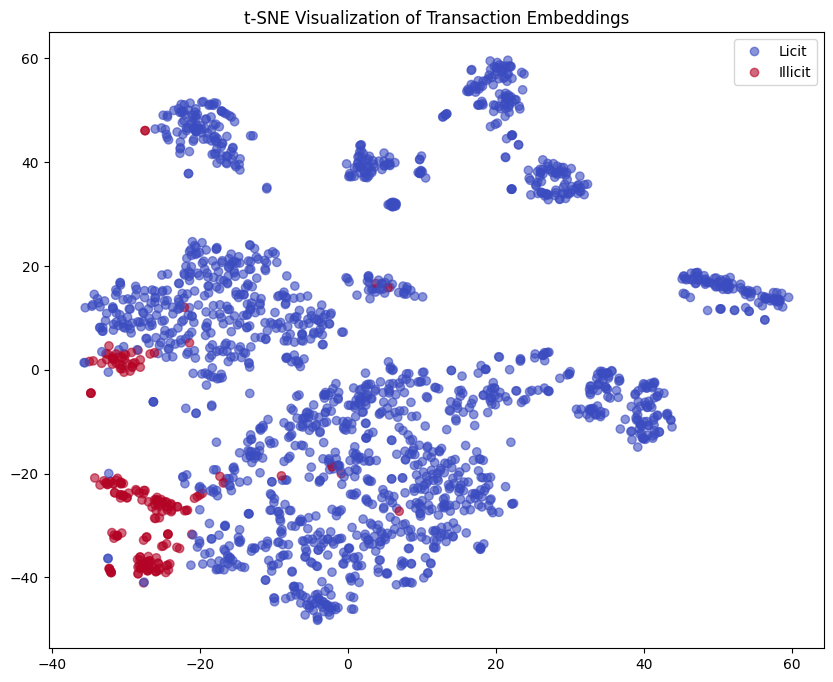

In [13]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get Embeddings (The 'Hidden State' before the final classifier)
model.eval()
with torch.no_grad():
    # We want the output of the first conv layer (128-dim) before the final classification layer
    h = model.conv1(data.x, data.edge_index)
    h = h.relu() # Apply activation as in forward pass
    # The embeddings are now 128-dimensional

    # Move to CPU for plotting
    embeddings = h[test_mask].cpu().numpy()
    labels = data.y[test_mask].cpu().numpy()

# 2. Run t-SNE (Squash 128 dim -> 2 dim)
# We limit to 2000 points so it runs fast
print("Running t-SNE... (This might take a minute)")
tsne = TSNE(n_components=2, random_state=42)
emb_2d = tsne.fit_transform(embeddings[:2000])
labels_2d = labels[:2000]

# 3. Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=labels_2d, cmap='coolwarm', alpha=0.6)
plt.title("t-SNE Visualization of Transaction Embeddings")
plt.legend(handles=scatter.legend_elements()[0], labels=['Licit', 'Illicit'])
plt.show()

Recovering from GPU error. Switching to CPU for retraining and explanation...
Retraining SAGEConv model on CPU...
Epoch 0: Loss 1.9203
Epoch 10: Loss 0.5527
Epoch 20: Loss 0.4057
Epoch 30: Loss 0.3284
Epoch 40: Loss 0.2806
Epoch 50: Loss 0.2473
Explaining Fraud Prediction for Node Index: 29897
Generating Subgraph Visualization...


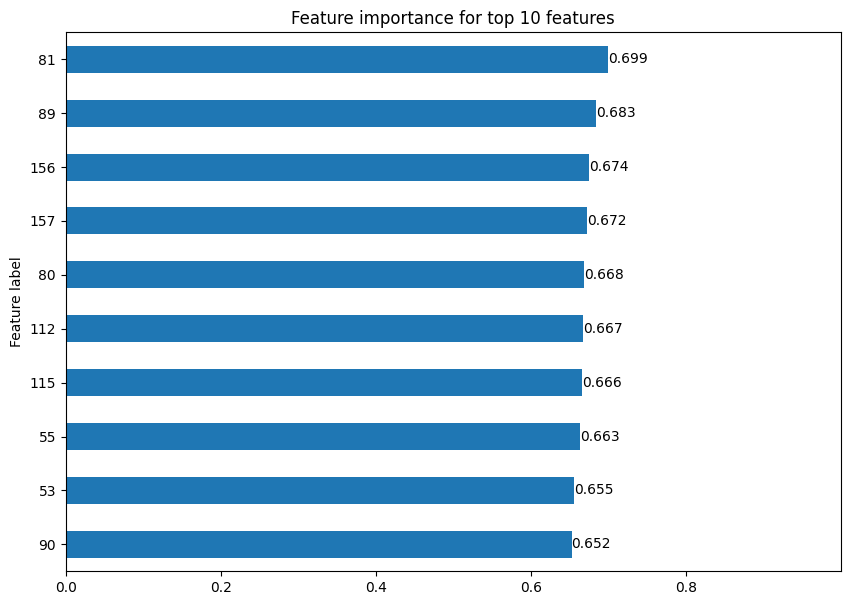

Graph visualization skipped due to: The attribute 'edge_mask' is not available in 'Explanation' (got ['node_mask'])


In [14]:
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from torch_geometric.explain import Explainer, GNNExplainer

# 1. HACK: Bypass Corrupted GPU
_orig_is_available = torch.cuda.is_available
torch.cuda.is_available = lambda: False

try:
    print("Recovering from GPU error. Switching to CPU for retraining and explanation...")
    device = torch.device('cpu')

    # 2. Re-create Data object on CPU
    src_nodes = df_edges_clean['txId1'].map(map_id).values
    dst_nodes = df_edges_clean['txId2'].map(map_id).values
    edge_index = torch.tensor([src_nodes, dst_nodes], dtype=torch.long)

    feature_cols = ['time_step'] + [f'feat_{i}' for i in range(165)]
    x = torch.tensor(df_merge[feature_cols].values, dtype=torch.float)
    y = torch.tensor(df_merge['label'].values, dtype=torch.float)

    data = Data(x=x, edge_index=edge_index, y=y)

    time_step = data.x[:, 0]
    train_mask = time_step <= 34
    test_mask = time_step > 34

    # 3. Define Model (SAGEConv)
    # We revert to SAGEConv as it is robust. We won't use edge masks.
    class FraudGNN(torch.nn.Module):
        def __init__(self, in_channels, hidden_channels, out_channels):
            super(FraudGNN, self).__init__()
            self.conv1 = SAGEConv(in_channels, hidden_channels)
            self.conv2 = SAGEConv(hidden_channels, out_channels)

        def forward(self, x, edge_index):
            x = self.conv1(x, edge_index)
            x = x.relu()
            x = F.dropout(x, p=0.5, training=self.training)
            x = self.conv2(x, edge_index)
            return x

    # 4. Initialize and Retrain on CPU
    model = FraudGNN(in_channels=data.num_features, hidden_channels=128, out_channels=1)
    model = model.to(device)
    data = data.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    weight = torch.tensor([data.y.shape[0] / data.y.sum().item()])
    criterion = torch.nn.BCEWithLogitsLoss(pos_weight=weight)

    print("Retraining SAGEConv model on CPU...")
    for epoch in range(51):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out[train_mask], data.y[train_mask].unsqueeze(1))
        loss.backward()
        optimizer.step()

        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Loss {loss.item():.4f}")

    # 5. Explainer Setup
    # Wrapper to output probabilities (Sigmoid) is CRITICAL for GNNExplainer
    class ProbModel(torch.nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model
        def forward(self, x, edge_index, **kwargs):
            # SAGEConv doesn't use edge_weight, so we ignore kwargs
            return self.model(x, edge_index).sigmoid()

    explainer = Explainer(
        model=ProbModel(model),
        algorithm=GNNExplainer(epochs=100),
        explanation_type='model',
        # We mask attributes (features) to see what's important.
        # We disable edge_mask because SAGEConv doesn't support it (would cause 'no grad' error).
        node_mask_type='attributes',
        edge_mask_type=None,
        model_config=dict(
            mode='binary_classification',
            task_level='node',
            return_type='probs',
        ),
    )

    # 6. Find a True Positive to explain
    model.eval()

    # Run inference to find a node to explain (No gradients needed here)
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = (torch.sigmoid(out) > 0.5).float()

        matches = (data.y == 1) & (pred.squeeze() == 1) & test_mask

    # Generate explanation (Gradients ARE needed here for GNNExplainer)
    if matches.sum() > 0:
        fraud_node_idx = matches.nonzero(as_tuple=True)[0][0].item()
        print(f"Explaining Fraud Prediction for Node Index: {fraud_node_idx}")

        # 7. Generate Explanation
        explanation = explainer(data.x, data.edge_index, index=fraud_node_idx)

        # 8. Visualize
        print("Generating Subgraph Visualization...")
        explanation.visualize_feature_importance(top_k=10)
        # visualize_graph might warn about missing edge_mask, but often plots structure anyway
        try:
            explanation.visualize_graph(path='fraud_explanation.png')
            print("Graph saved as 'fraud_explanation.png'")
        except Exception as e:
            print(f"Graph visualization skipped due to: {e}")
    else:
        print("No true positive frauds found in test set after retraining.")

finally:
    # Restore the original function
    torch.cuda.is_available = _orig_is_available

Loading RAW data to capture 'Unknown' nodes...
👑 Found Real Kingpin: Transaction 30179316
Total Connections (including Unknowns): 177
Plotting 178 nodes...


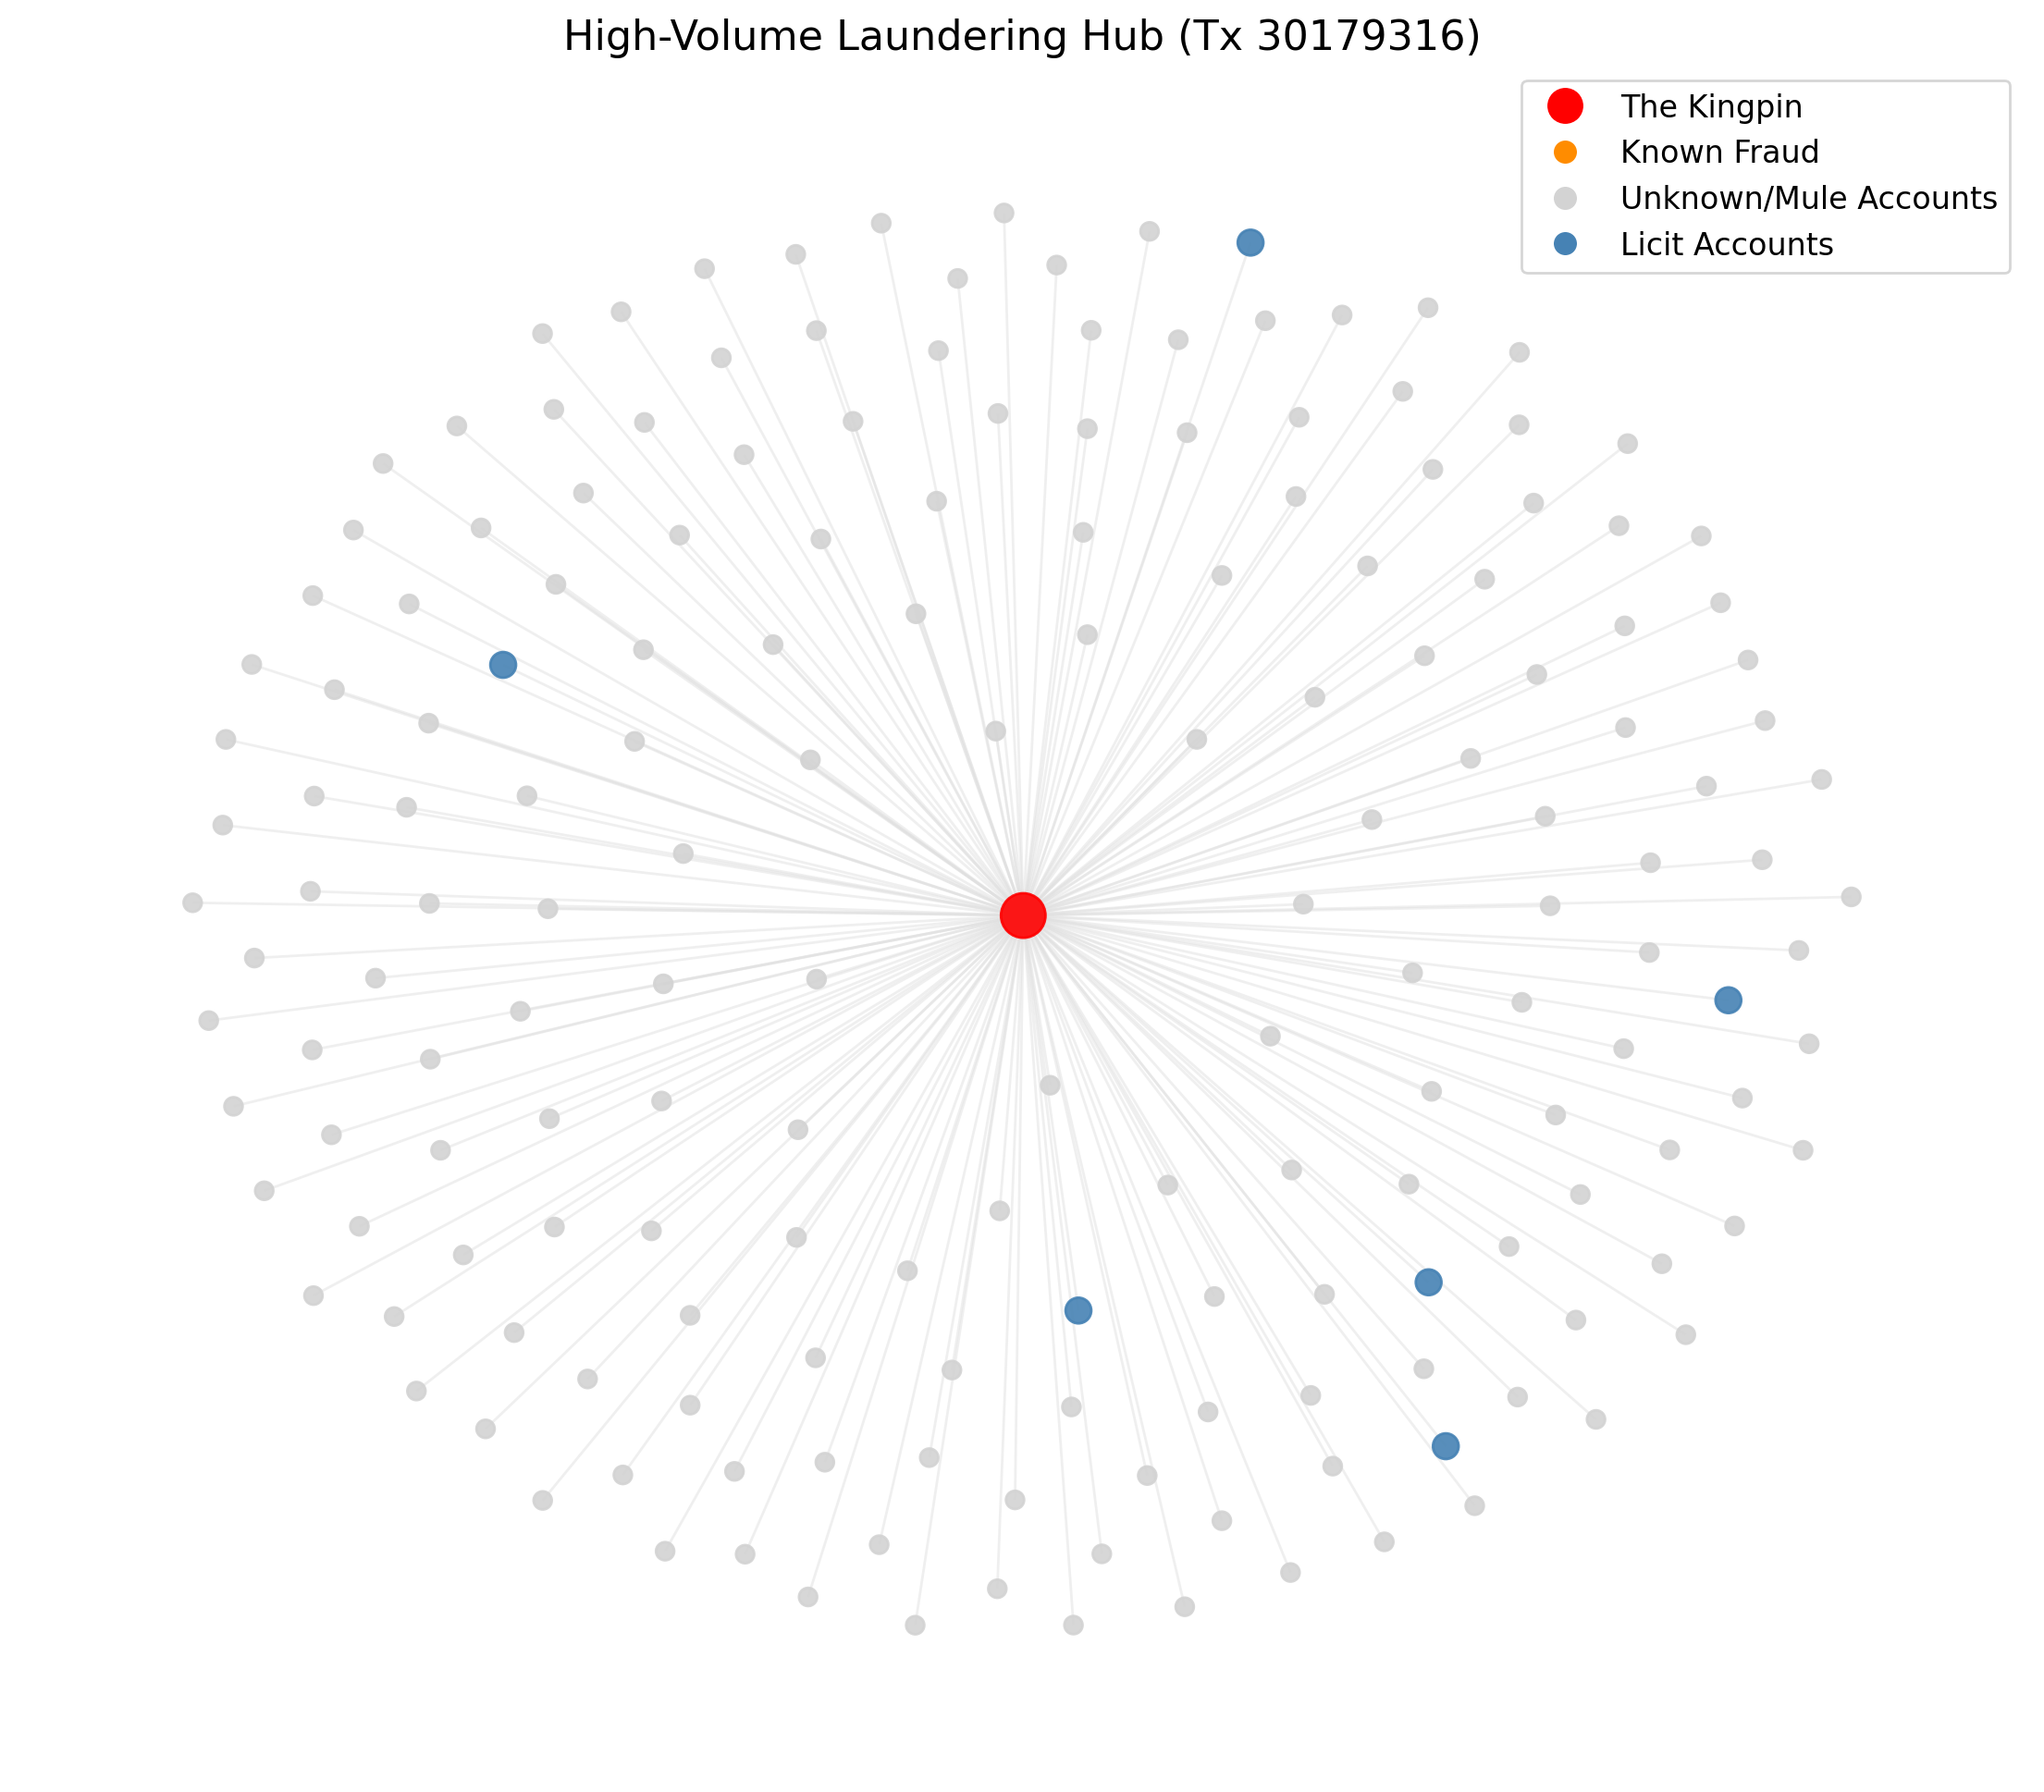

In [18]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os
from google.colab import files

def generate_uncensored_money_shot():
    print("Loading RAW data to capture 'Unknown' nodes...")

    # Define the path where data was downloaded
    base_path = '/content/drive/MyDrive/Projects/bitcoinFraudDetection'

    # 1. Load Raw CSVs from the correct path
    classes_path = os.path.join(base_path, 'elliptic_txs_classes.csv')
    edges_path = os.path.join(base_path, 'elliptic_txs_edgelist.csv')

    if not os.path.exists(classes_path) or not os.path.exists(edges_path):
        raise FileNotFoundError(f"Data files not found at {base_path}. Please check the download step.")

    df_classes = pd.read_csv(classes_path)
    df_edges = pd.read_csv(edges_path)

    # 2. Identify the Fraudster with the MOST raw connections
    # Filter for only confirmed Illicit transactions (Class '1')
    illicit_ids = df_classes[df_classes['class'] == '1']['txId']

    # Count how often each illicit ID appears in the edge list
    # (Source or Target)
    counts = pd.concat([
        df_edges[df_edges['txId1'].isin(illicit_ids)]['txId1'],
        df_edges[df_edges['txId2'].isin(illicit_ids)]['txId2']
    ]).value_counts()

    kingpin_id = counts.idxmax()
    kingpin_connections = counts.max()

    print(f"👑 Found Real Kingpin: Transaction {kingpin_id}")
    print(f"Total Connections (including Unknowns): {kingpin_connections}")

    # 3. Extract the 1-Hop Neighborhood (Raw)
    # Get all edges where the Kingpin is involved
    subset_edges = df_edges[
        (df_edges['txId1'] == kingpin_id) |
        (df_edges['txId2'] == kingpin_id)
    ]

    # Create Graph
    G = nx.from_pandas_edgelist(subset_edges, 'txId1', 'txId2')

    # 4. Color Coding
    node_colors = []
    node_sizes = []

    # create a lookup for classes
    class_map = df_classes.set_index('txId')['class'].to_dict()

    print(f"Plotting {len(G.nodes())} nodes...")

    for node in G.nodes():
        if node == kingpin_id:
            node_colors.append('#FF0000') # RED: Kingpin
            node_sizes.append(300)
        else:
            # Check class
            cls = class_map.get(node, 'unknown')
            if cls == '1':
                node_colors.append('#FF8C00') # ORANGE: Illicit
                node_sizes.append(100)
            elif cls == '2':
                node_colors.append('#4682B4') # BLUE: Licit
                node_sizes.append(100)
            else:
                node_colors.append('#D3D3D3') # GREY: Unknown (The "Mules")
                node_sizes.append(50)

    # 5. Plot
    plt.figure(figsize=(14, 12), dpi=200)
    # Using 'spring_layout' with k=0.15 to spread nodes out nicely
    pos = nx.spring_layout(G, k=0.15, iterations=20, seed=42)

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
    nx.draw_networkx_edges(G, pos, edge_color='#E0E0E0', alpha=0.5, width=1.0)

# Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF0000', label='The Kingpin', markersize=15),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF8C00', label='Known Fraud', markersize=10),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#D3D3D3', label='Unknown/Mule Accounts', markersize=10),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#4682B4', label='Licit Accounts', markersize=10) # <--- Added this line
    ]
    plt.legend(handles=legend_elements, loc='upper right', fontsize=12)
    plt.legend(handles=legend_elements, loc='upper right', fontsize=12)
    plt.title(f"High-Volume Laundering Hub (Tx {kingpin_id})", fontsize=16)
    plt.axis('off')

generate_uncensored_money_shot()